In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor

pd.set_option('display.max_rows', 150)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
col_names = ['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety', 'class']
url = '/content/drive/My Drive/datasets/car.data'

df = pd.read_csv(url, header=None, names=col_names)

In [ ]:
df.head()

,buying,maint,doors,persons,lug_boot,safety,class
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc


In [ ]:
df.info()

df.describe(include='object').T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1728 entries, 0 to 1727
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   buying    1728 non-null   object
 1   maint     1728 non-null   object
 2   doors     1728 non-null   object
 3   persons   1728 non-null   object
 4   lug_boot  1728 non-null   object
 5   safety    1728 non-null   object
 6   class     1728 non-null   object
dtypes: object(7)
memory usage: 94.6+ KB


,count,unique,top,freq
buying,1728,4,vhigh,432
maint,1728,4,vhigh,432
doors,1728,4,2,432
persons,1728,3,2,576
lug_boot,1728,3,small,576
safety,1728,3,low,576
class,1728,4,unacc,1210


In [ ]:
df.dtypes

,0
buying,object
maint,object
doors,object
persons,object
lug_boot,object
safety,object
class,object


In [ ]:
df.isna().sum()

,0
buying,0
maint,0
doors,0
persons,0
lug_boot,0
safety,0
class,0


In [ ]:
df['class'].value_counts()

,count
class,
unacc,1210
acc,384
good,69
vgood,65


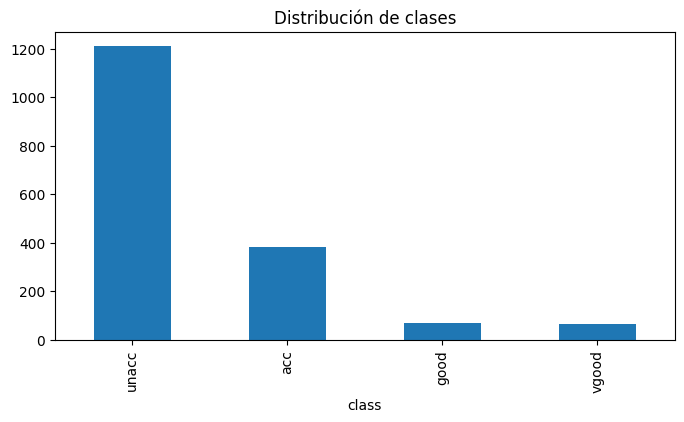

In [ ]:
df['class'].value_counts().plot( kind='bar', figsize=(8,4), title='Distribución de clases')
plt.show()

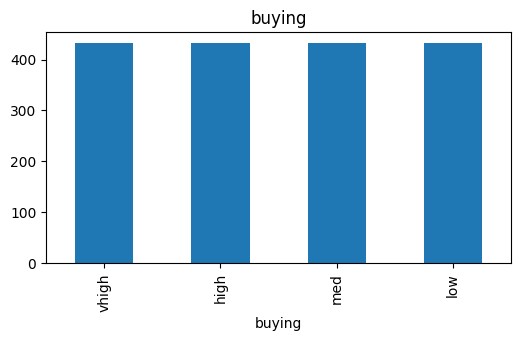

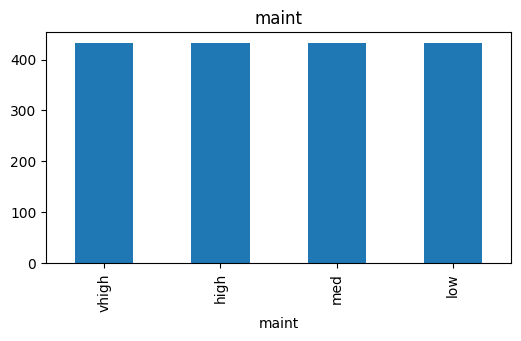

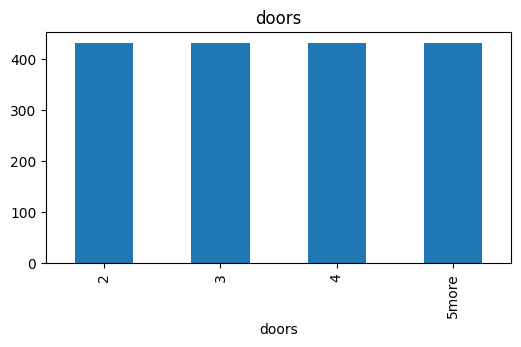

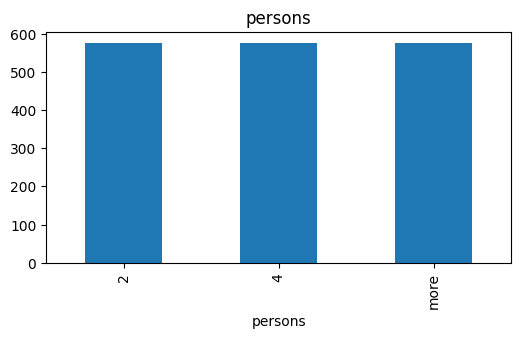

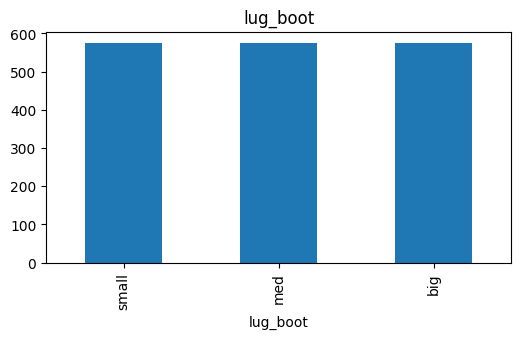

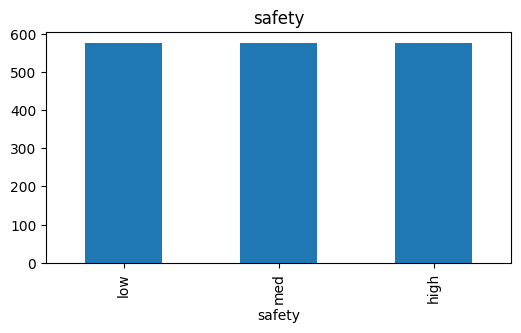

In [ ]:
for col in df.columns[:-1]:
    plt.figure(figsize=(6,3))
    df[col].value_counts().plot(kind='bar')
    plt.title(col)
    plt.show()

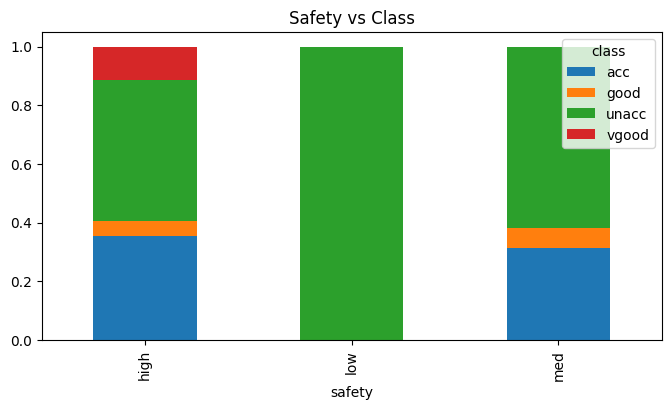

In [ ]:
pd.crosstab( df['safety'], df['class'], normalize='index').plot(kind='bar', stacked=True, figsize=(8,4))

plt.title('Safety vs Class')
plt.show()

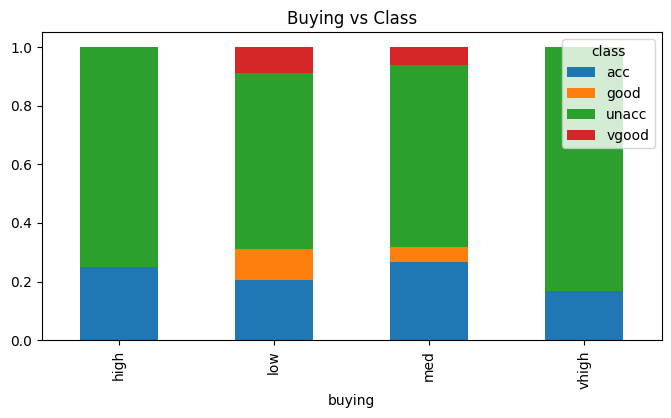

In [ ]:
pd.crosstab( df['buying'], df['class'], normalize='index').plot(kind='bar', stacked=True, figsize=(8,4))

plt.title('Buying vs Class')
plt.show()

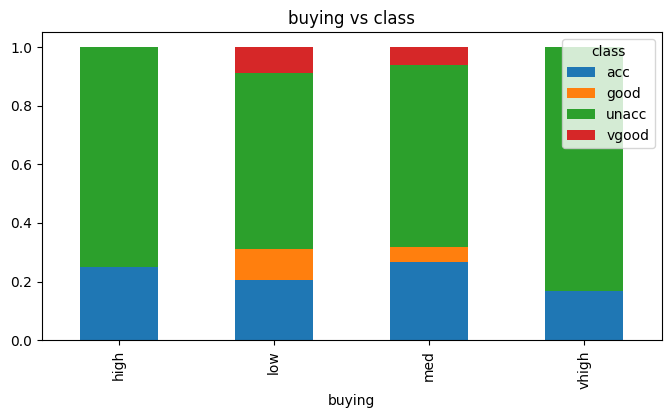

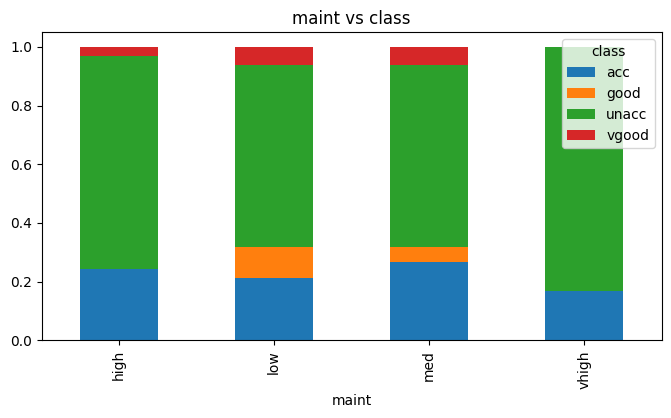

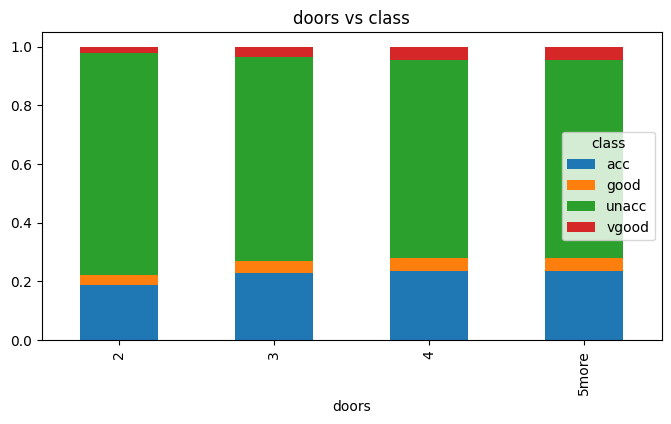

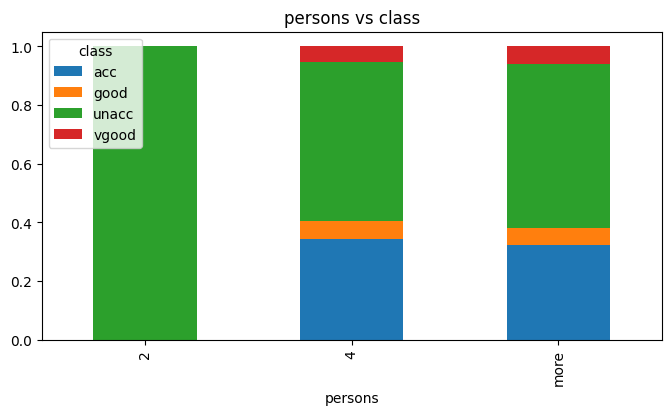

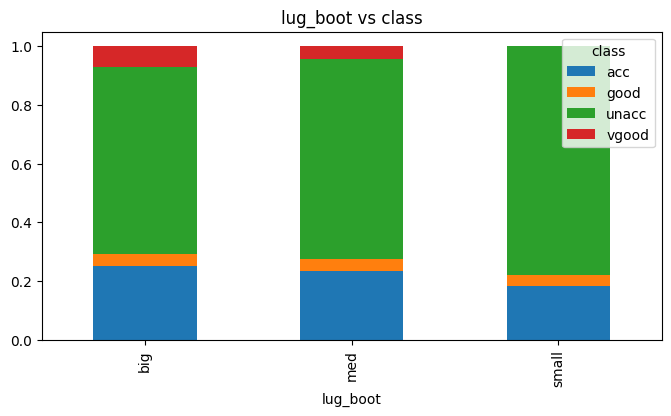

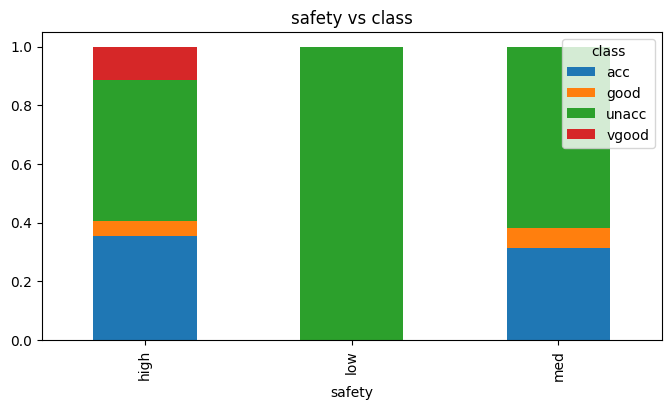

In [ ]:
for col in df.columns[:-1]:

    pd.crosstab( df[col], df['class'],normalize='index')\
      .plot(kind='bar', stacked=True, figsize=(8,4) )

    plt.title(f'{col} vs class')
    plt.show()

In [ ]:
X = df.drop('class', axis=1)
y = df['class']

X = pd.get_dummies(X)

In [ ]:
X.head()

,buying_high,buying_low,buying_med,buying_vhigh,maint_high,maint_low,maint_med,maint_vhigh,doors_2,doors_3,...,doors_5more,persons_2,persons_4,persons_more,lug_boot_big,lug_boot_med,lug_boot_small,safety_high,safety_low,safety_med
0,False,False,False,True,False,False,False,True,True,False,...,False,True,False,False,False,False,True,False,True,False
1,False,False,False,True,False,False,False,True,True,False,...,False,True,False,False,False,False,True,False,False,True
2,False,False,False,True,False,False,False,True,True,False,...,False,True,False,False,False,False,True,True,False,False
3,False,False,False,True,False,False,False,True,True,False,...,False,True,False,False,False,True,False,False,True,False
4,False,False,False,True,False,False,False,True,True,False,...,False,True,False,False,False,True,False,False,False,True


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier( n_estimators=300, random_state=42)

rf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=300, random_state=42)

In [ ]:
y_pred = rf.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred)

0.976878612716763

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         acc       0.94      0.96      0.95        77
        good       1.00      0.93      0.96        14
       unacc       0.99      0.99      0.99       242
       vgood       0.92      0.92      0.92        13

    accuracy                           0.98       346
   macro avg       0.96      0.95      0.96       346
weighted avg       0.98      0.98      0.98       346



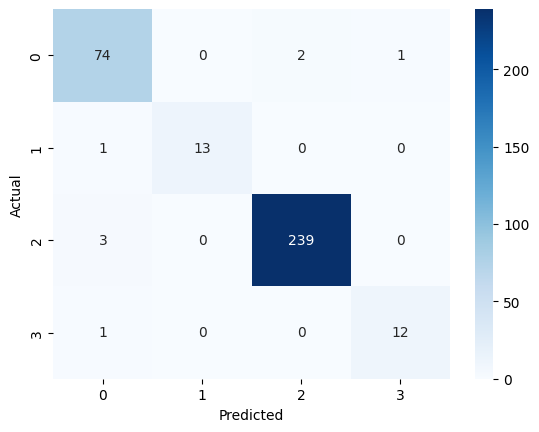

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

sns.heatmap( cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

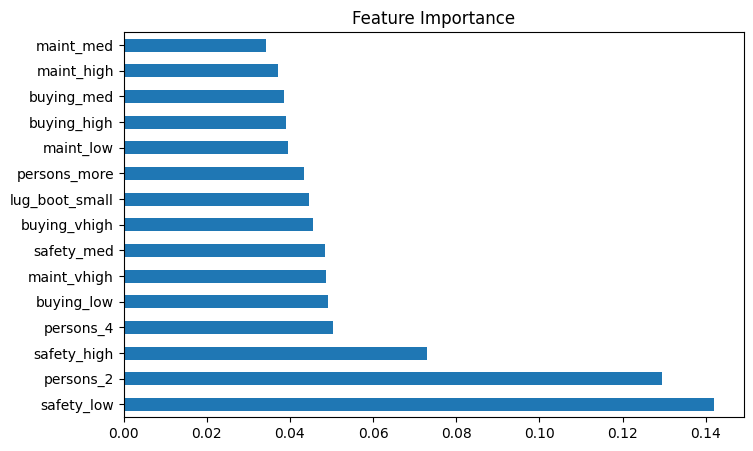

In [ ]:
importances = pd.Series( rf.feature_importances_, index=X.columns).sort_values(ascending=False)

importances.head(15).plot( kind='barh', figsize=(8,5))

plt.title('Feature Importance')
plt.show()